# 06 — Before / After Improvement Analysis

## Objective

Summarize the overall effect of LSS by combining:

- OEE improvement
- Availability, Performance, and Quality changes
- unplanned downtime changes
- reliability changes
- remaining production losses

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

RAW_DIR = PROJECT_ROOT / "data" / "raw"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
oee_before = pd.read_csv(RAW_DIR / "OEEdataset.csv")
oee_after = pd.read_csv(RAW_DIR / "OEEdataset_afterLSS.csv")

for df in [oee_before, oee_after]:
    df.dropna(axis=1, how="all", inplace=True)
    df.dropna(axis=0, how="all", inplace=True)

oee_before = oee_before.rename(columns={
    "Sumof goodProductionTimeSec": "good_production_time_sec",
    "Sum of slowProductionTimeSec": "slow_production_time_sec",
    "Sum of unplannedStopsTimeSec": "unplanned_stop_time_sec"
})

oee_after = oee_after.rename(columns={
    "Sum of goodProdction": "good_production_time_sec",
    "Sum of slowProduction": "slow_production_time_sec",
    "Sum of unplannedStopsTimeSec": "unplanned_stop_time_sec"
})

In [4]:
downtime_before = pd.read_csv(RAW_DIR / "DowntimeDataset.csv")
downtime_after = pd.read_csv(RAW_DIR / "DowntimeDataset_afterLSS.csv")

for df in [downtime_before, downtime_after]:
    df.dropna(axis=1, how="all", inplace=True)
    df.dropna(axis=0, how="all", inplace=True)

downtime_before = downtime_before.rename(columns={
    "StopGroup": "stop_group",
    "StopType": "stop_type",
    "StopDuration(min)": "duration_min"
})

downtime_after = downtime_after.rename(columns={
    "Stop group": "stop_group",
    "Stop type": "stop_type",
    "Stop duration (min) (TTR)": "duration_min"
})

C:\Users\erenk\AppData\Local\Temp\ipykernel_16952\307615481.py:2: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  downtime_after = pd.read_csv(RAW_DIR / "DowntimeDataset_afterLSS.csv")


In [5]:
failure_before = downtime_before[
    downtime_before["stop_group"] == "FAILURE"
]

failure_after = downtime_after[
    downtime_after["stop_group"] == "FAILURE"
]

runtime_before_hours = (
    oee_before["good_production_time_sec"].sum()
    + oee_before["slow_production_time_sec"].sum()
) / 3600

runtime_after_hours = (
    oee_after["good_production_time_sec"].sum()
    + oee_after["slow_production_time_sec"].sum()
) / 3600

final_summary = pd.DataFrame({
    "Metric": [
        "OEE (%)",
        "Availability (%)",
        "Performance (%)",
        "Quality (%)",
        "Unplanned Downtime (min/day)",
        "MTBF (hours)",
        "MTTR (min)"
    ],
    "Before LSS": [
        oee_before["OEE"].mean() * 100,
        oee_before["Availability"].mean() * 100,
        oee_before["Performance"].mean() * 100,
        oee_before["Quality"].mean() * 100,
        oee_before["unplanned_stop_time_sec"].mean() / 60,
        runtime_before_hours / len(failure_before),
        failure_before["duration_min"].mean()
    ],
    "After LSS": [
        oee_after["OEE"].mean() * 100,
        oee_after["Availability"].mean() * 100,
        oee_after["Performance"].mean() * 100,
        oee_after["Quality"].mean() * 100,
        oee_after["unplanned_stop_time_sec"].mean() / 60,
        runtime_after_hours / len(failure_after),
        failure_after["duration_min"].mean()
    ]
})

final_summary["Change"] = (
    final_summary["After LSS"]
    - final_summary["Before LSS"]
)

final_summary.round(2)

,Metric,Before LSS,After LSS,Change
0,OEE (%),59.07,64.30,5.23
1,Availability (%),64.37,69.73,5.36
2,Performance (%),92.93,95.01,2.07
3,Quality (%),98.35,97.05,-1.30
4,Unplanned Downtime (min/day),99.68,95.32,-4.36
5,MTBF (hours),1.47,1.92,0.46
6,MTTR (min),14.57,14.57,0.00


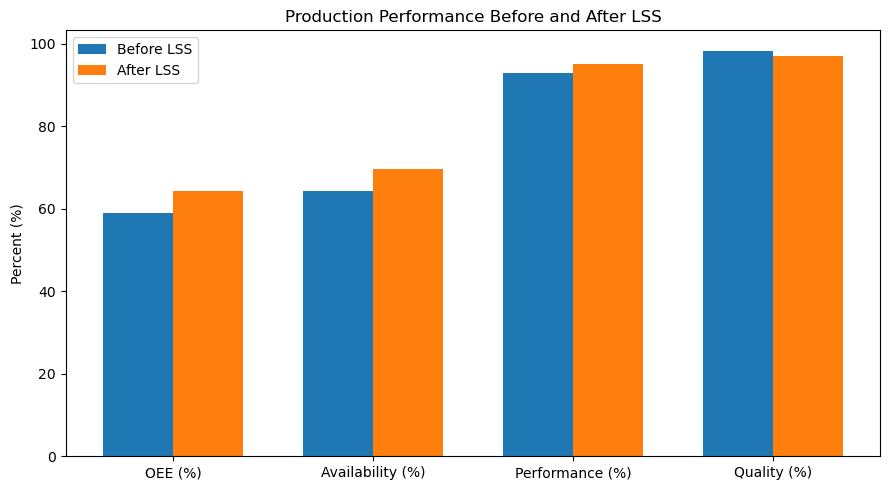

In [6]:
component_plot = final_summary[
    final_summary["Metric"].isin([
        "OEE (%)",
        "Availability (%)",
        "Performance (%)",
        "Quality (%)"
    ])
].copy()

x = range(len(component_plot))

plt.figure(figsize=(9, 5))

width = 0.35

plt.bar(
    [i - width/2 for i in x],
    component_plot["Before LSS"],
    width=width,
    label="Before LSS"
)

plt.bar(
    [i + width/2 for i in x],
    component_plot["After LSS"],
    width=width,
    label="After LSS"
)

plt.xticks(x, component_plot["Metric"])
plt.ylabel("Percent (%)")
plt.title("Production Performance Before and After LSS")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "production_performance_before_after_lss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Final Business Findings

The LSS period was associated with an improvement in overall production performance:

- OEE increased from **59.1% to 64.3%** (+5.2 percentage points).
- Availability improved by **5.4 percentage points**, representing the strongest OEE component improvement.
- Performance increased by **2.1 percentage points**.
- Quality decreased slightly by **1.3 percentage points**.
- Average unplanned downtime decreased from **99.7 to 95.3 min/day**.
- MTBF increased from **1.47 to 1.92 hours**, indicating fewer failures relative to operating time.
- MTTR remained approximately unchanged at **14.6 minutes**.

The improvement was primarily driven by higher equipment availability and fewer failures rather than faster repair or quality gains.

After LSS, the loss profile shifted. **Rack Starvation** emerged as a major material-flow constraint, while **Mechanical Failure** and **Manual Brick Handling** remained important sources of downtime.

These areas represent the main opportunities for the next continuous-improvement cycle.